# Analisis Sentimen Ulasan Produk Tokopedia 2025

Notebook mencakup pengambilan data, eksplorasi, preprocessing teks bahasa Indonesia,
pelatihan dan evaluasi Logistic Regression, visualisasi, serta eksperimen IndoBERT.

## 1. Persiapan lingkungan

In [6]:
%pip install -q kagglehub Sastrawi wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.3 MB/s eta 0:00:00


In [7]:
import re
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud

RANDOM_STATE = 42
LABELS = ["negative", "neutral", "positive"]
sns.set_theme(style="whitegrid")


## 2. Memuat dataset

In [8]:
dataset_dir = Path(kagglehub.dataset_download("salmanabdu/tokopedia-product-reviews-2025"))
csv_path = next(dataset_dir.glob("*.csv"))
df = pd.read_csv(csv_path)

print(f"Dataset: {csv_path.name}")
print(f"Ukuran: {df.shape[0]:,} baris × {df.shape[1]} kolom")
display(df.head())

100%|██████████| 3.54M/3.54M [00:00<00:00, 117MB/s]

Extracting files...


Dataset: tokopedia_product_reviews_2025.csv
Ukuran: 65,543 baris × 13 kolom


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


## 3. Eksplorasi Data (EDA)

In [9]:
df.info()
display(df.describe(include="all"))
display(df.isna().sum().rename("missing_values"))
display(df["rating"].value_counts().sort_index().rename("jumlah"))
display(df["sentiment_label"].value_counts().rename("jumlah"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   26749 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
count,65543,65543,6.554300e+04,65543,65543,26749,6.554300e+04,65543,6.554300e+04,65543.000000,65543.000000,6.554300e+04,65543
unique,58068,2845,NaN,5418,6,5511,NaN,5521,NaN,NaN,NaN,NaN,3
top,Bagus,2025-10-15,NaN,Chosamon Mid Top Original Sepatu Sneakers Olah...,Makanan & Minuman,Default,NaN,https://www.tokopedia.com/sasaofficial/sasa-te...,NaN,NaN,NaN,NaN,positive
freq,323,83,NaN,80,17859,1733,NaN,20,NaN,NaN,NaN,NaN,63943
mean,NaN,NaN,9.814143e+08,NaN,NaN,NaN,5.421295e+05,NaN,2.447482e+10,4.893764,1954.923897,7.615674e+16,NaN
std,NaN,NaN,4.193324e+08,NaN,NaN,NaN,2.365557e+06,NaN,3.870717e+10,0.492495,18244.026827,7.516573e+17,NaN
min,NaN,NaN,1.027202e+07,NaN,NaN,NaN,1.000000e+02,NaN,4.298375e+06,1.000000,6.000000,6.050000e+02,NaN
25%,NaN,NaN,7.182240e+08,NaN,NaN,NaN,2.990000e+04,NaN,1.446882e+09,5.000000,100.000000,2.298522e+06,NaN
50%,NaN,NaN,9.740048e+08,NaN,NaN,NaN,8.000000e+04,NaN,4.769575e+09,5.000000,500.000000,5.801280e+06,NaN
75%,NaN,NaN,1.145967e+09,NaN,NaN,NaN,2.146870e+05,NaN,1.534605e+10,5.000000,1000.000000,9.061811e+06,NaN


,missing_values
review_text,0
review_date,0
review_id,0
product_name,0
product_category,0
product_variant,38794
product_price,0
product_url,0
product_id,0
rating,0


,jumlah
rating,
1,547
2,251
3,802
4,2418
5,61525


,jumlah
sentiment_label,
positive,63943
neutral,802
negative,798


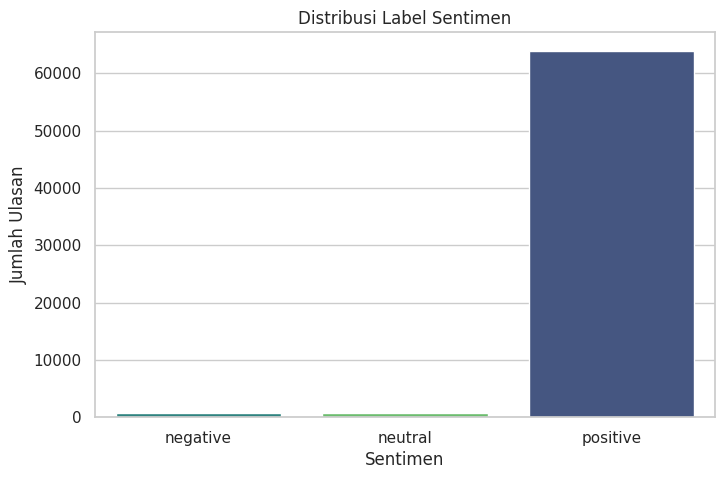

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="sentiment_label",
    order=LABELS,
    hue="sentiment_label",
    palette="viridis",
    legend=False,
)
plt.title("Distribusi Label Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.show()

## 4. Preprocessing teks

In [11]:
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return stopword_remover.remove(text)

sample_text = df["review_text"].dropna().iloc[0]
print("Sebelum:", sample_text)
print("Sesudah:", clean_text(sample_text))

Sebelum: baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli terlur ayam mentah , sec online. tp ternyata packing liar biasa. rapi, aman. Kerem seller
Sesudah: baru sekali terima brg dr belanja online dg packing super rapih aman semula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online tp ternyata packing liar biasa rapi aman kerem seller


In [12]:
stemmer = StemmerFactory().create_stemmer()

def clean_text_advanced(text):
    return stemmer.stem(clean_text(text))

print(f"Sebelum stemming: {sample_text[:50]}...")
print(f"Sesudah stemming: {clean_text_advanced(sample_text)}")


Sebelum stemming: baru sekali ini terima brg dr belanja online dg pa...
Sesudah stemming: baru sekali terima brg dr belanja online dg packing super rapih aman mula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online tp nyata packing liar biasa rapi aman rem seller


### 4.1 Pengembangan Preprocessing: Normalisasi & Emotikon
Bagian ini menambahkan kamus slang dan pembersihan emotikon untuk meningkatkan kualitas fitur teks.

In [25]:
slang_dict = {
    "bgt": "banget", "bgtt": "banget", "jd": "jadi", "ga": "tidak",
    "gak": "tidak", "tdk": "tidak", "sdh": "sudah", "udah": "sudah",
    "brg": "barang", "krn": "karena", "cpt": "cepat", "jg": "juga",
    "tp": "tapi", "kalo": "kalau", "dgn": "dengan", "dr": "dari",
    "ori": "original", "mksh": "terima kasih", "tks": "terima kasih"
}

emoticon_map = {
    "😊": " senang ", "🙂": " senang ", "😄": " senang ", "😍": " suka ",
    "👍": " bagus ", "👌": " bagus ", "⭐": " bintang ",
    "😞": " kecewa ", "😟": " kecewa ", "😠": " marah ", "😡": " marah ",
    "👎": " buruk ", "😢": " sedih ", "😭": " sedih "
}

def normalize_slang(text):
    words = text.split()
    return " ".join([slang_dict.get(w, w) for w in words])

def convert_emoticons(text):
    for emo, replacement in emoticon_map.items():
        text = text.replace(emo, replacement)
    return text

def clean_text_final(text):
    # 1. Konversi emotikon dulu sebelum dihapus oleh regex
    text = convert_emoticons(str(text))
    # 2. Pembersihan dasar
    text = clean_text(text)
    # 3. Normalisasi slang
    text = normalize_slang(text)
    # 4. Stemming
    return stemmer.stem(text)

# Uji coba
test_slang = "barangnya bgt bagus, tp pengiriman agak lama jd kecewa 😊"
print(f"Original: {test_slang}")
print(f"Processed: {clean_text_final(test_slang)}")

Original: barangnya bgt bagus, tp pengiriman agak lama jd kecewa 😊
Processed: barang banget bagus tapi kirim lama jadi kecewa senang


### 4.2 Augmentasi Teks (Oversampling Manual)
Untuk menambah variasi pada kelas minoritas, kita akan menggunakan teknik penggantian sinonim sederhana.

In [26]:
import random

synonym_dict = {
    "bagus": ["baik", "oke", "mantap", "keren"],
    "buruk": ["jelek", "kurang", "parah"],
    "kecewa": ["kesal", "nyesel", "sedih"],
    "cepat": ["kilat", "gegas", "ekspres"],
    "lama": ["lambat", "lelet", "telat"]
}

def augment_text(text):
    words = text.split()
    new_words = words.copy()
    for i, word in enumerate(words):
        if word in synonym_dict:
            if random.random() > 0.5:
                new_words[i] = random.choice(synonym_dict[word])
    return " ".join(new_words)

# Contoh augmentasi untuk kelas 'negative'
neg_samples = df[df['sentiment_label'] == 'negative']['review_text'].iloc[:2]
for txt in neg_samples:
    print(f"Original: {txt[:50]}...")
    print(f"Augmented: {augment_text(txt)[:50]}...")

Original: telor busuk semua 20 butir gak ada yg bagus 1 pun....
Augmented: telor busuk semua 20 butir gak ada yg baik 1 pun.....
Original: Kualitas barang tidak rata, ada yg kecil kurang da...
Augmented: Kualitas barang tidak rata, ada yg kecil kurang da...


### 5.1 Implementasi SMOTE
Kita akan menggunakan `imbalanced-learn` untuk menyeimbangkan fitur hasil TF-IDF secara sintetis.

In [27]:
%pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

# 1. Gunakan data yang lebih banyak untuk awal
df_smote = df.sample(n=5000, random_state=RANDOM_STATE).copy()
df_smote['clean_text'] = df_smote['review_text'].apply(clean_text_final)

# 2. Vektorisasi
tfidf_smote = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf_smote.fit_transform(df_smote['clean_text'])
y = df_smote['sentiment_label']

# 3. Terapkan SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_resampled, y_resampled = smote.fit_resample(X_tfidf, y)

print("Jumlah data sebelum SMOTE:", y.value_counts().to_dict())
print("Jumlah data setelah SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Jumlah data sebelum SMOTE: {'positive': 4863, 'neutral': 70, 'negative': 67}
Jumlah data setelah SMOTE: {'positive': 4863, 'negative': 4863, 'neutral': 4863}


In [28]:
# 4. Latih model dengan data hasil SMOTE
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=RANDOM_STATE
)

smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_s, y_train_s)

y_pred_s = smote_model.predict(X_test_s)
print("Laporan Klasifikasi (SMOTE + Augmentasi):")
print(classification_report(y_test_s, y_pred_s))

Laporan Klasifikasi (SMOTE + Augmentasi):
              precision    recall  f1-score   support

    negative       0.99      1.00      0.99      1001
     neutral       0.96      0.98      0.97       916
    positive       0.99      0.96      0.97      1001

    accuracy                           0.98      2918
   macro avg       0.98      0.98      0.98      2918
weighted avg       0.98      0.98      0.98      2918



## 5. Pelatihan model baseline

In [13]:
n_samples = 700
balanced_parts = []

for label in LABELS:
    group = df[df["sentiment_label"] == label]
    balanced_parts.append(
        group.sample(
            n=n_samples,
            replace=len(group) < n_samples,
            random_state=RANDOM_STATE,
        )
    )

df_balanced = pd.concat(balanced_parts, ignore_index=True)
df_balanced["clean_text"] = df_balanced["review_text"].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["clean_text"],
    df_balanced["sentiment_label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced["sentiment_label"],
)

baseline_tfidf = TfidfVectorizer(max_features=2_000)
X_train_tfidf = baseline_tfidf.fit_transform(X_train)
X_test_tfidf = baseline_tfidf.transform(X_test)

baseline_model = LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)
baseline_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## 6. Evaluasi model baseline

              precision    recall  f1-score   support

    negative       0.61      0.61      0.61       140
     neutral       0.54      0.53      0.53       140
    positive       0.82      0.83      0.82       140

    accuracy                           0.66       420
   macro avg       0.66      0.66      0.66       420
weighted avg       0.66      0.66      0.66       420



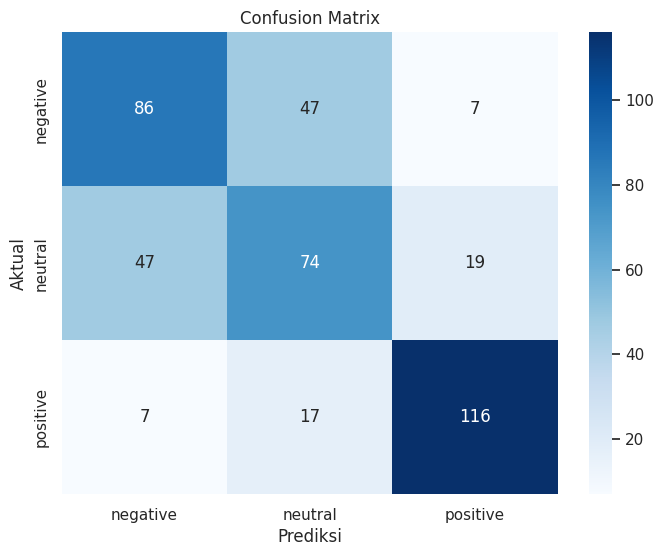

In [14]:
y_pred = baseline_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, labels=LABELS, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=LABELS)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

## 7. Optimasi hyperparameter

In [15]:
df_balanced["clean_text"] = df_balanced["review_text"].apply(clean_text_advanced)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["clean_text"],
    df_balanced["sentiment_label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced["sentiment_label"],
)

pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)),
    ]
)
param_grid = {
    "tfidf__max_features": [1_000, 2_000, 3_000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1, 10],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="f1_macro",
)
grid_search.fit(X_train, y_train)

print(f"Parameter terbaik: {grid_search.best_params_}")
print(f"Skor CV terbaik: {grid_search.best_score_:.4f}")


Parameter terbaik: {'clf__C': 1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Skor CV terbaik: 0.6559


In [16]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("Hasil setelah tuning")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        labels=LABELS,
        zero_division=0,
    )
)


Hasil setelah tuning
              precision    recall  f1-score   support

    negative       0.60      0.62      0.61       140
     neutral       0.54      0.51      0.53       140
    positive       0.80      0.81      0.81       140

    accuracy                           0.65       420
   macro avg       0.65      0.65      0.65       420
weighted avg       0.65      0.65      0.65       420



## 8. Visualisasi kata dominan

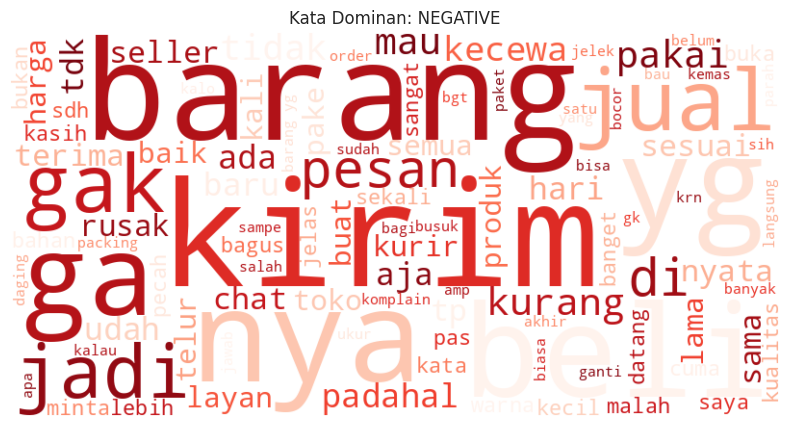

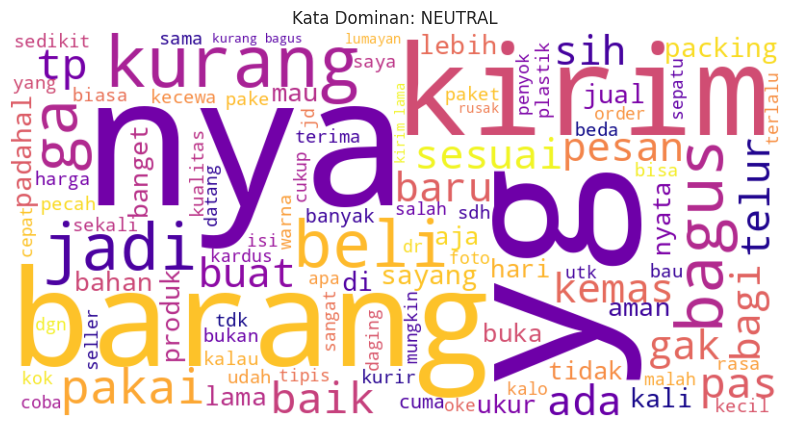

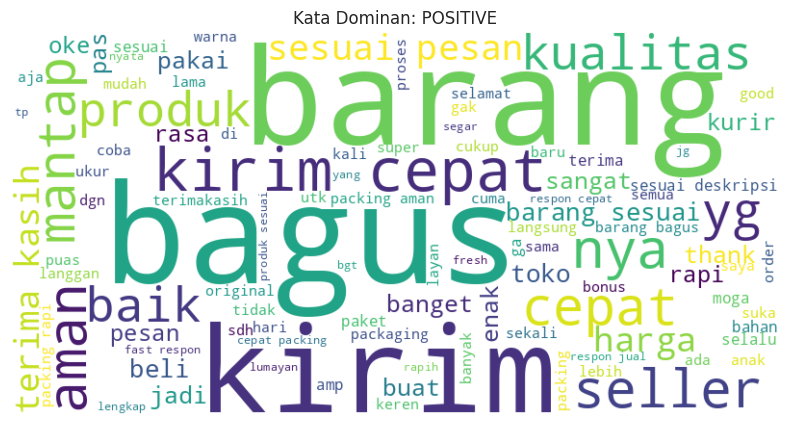

In [17]:
def show_wordcloud(sentiment, colormap):
    text = " ".join(
        df_balanced.loc[
            df_balanced["sentiment_label"] == sentiment, "clean_text"
        ]
    )
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=colormap,
        max_words=100,
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Kata Dominan: {sentiment.upper()}")
    plt.show()

for sentiment, colormap in zip(LABELS, ["Reds", "plasma", "viridis"]):
    show_wordcloud(sentiment, colormap)

## 9. Prediksi ulasan baru

In [18]:
def prediksi_sentimen(teks):
    teks_bersih = clean_text(teks)
    vektor = baseline_tfidf.transform([teks_bersih])
    return baseline_model.predict(vektor)[0]


contoh_ulasan = [
    "Barangnya rusak saat sampai",
    "Bagus banget, pengiriman cepat",
    "Biasa saja, lumayan",
]

for ulasan in contoh_ulasan:
    print(f"{ulasan!r}: {prediksi_sentimen(ulasan)}")

'Barangnya rusak saat sampai': negative
'Bagus banget, pengiriman cepat': positive
'Biasa saja, lumayan': neutral


## 10. Alternatif: Class Weighting

Eksperimen ini memakai subset data lebih besar dan `class_weight="balanced"` untuk
menangani ketidakseimbangan kelas tanpa undersampling.

In [19]:
df_large = df.sample(n=min(10_000, len(df)), random_state=RANDOM_STATE).copy()
df_large["clean_text"] = df_large["review_text"].apply(clean_text)

X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(
    df_large["clean_text"],
    df_large["sentiment_label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_large["sentiment_label"],
)

weighted_model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=3_000)),
        (
            "clf",
            LogisticRegression(
                max_iter=1_000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
weighted_model.fit(X_train_large, y_train_large)

y_pred_large = weighted_model.predict(X_test_large)
print("Laporan klasifikasi dengan class weighting:")
print(
    classification_report(
        y_test_large,
        y_pred_large,
        labels=LABELS,
        zero_division=0,
    )
)

Laporan klasifikasi dengan class weighting:
              precision    recall  f1-score   support

    negative       0.19      0.36      0.25        25
     neutral       0.09      0.27      0.13        26
    positive       0.99      0.95      0.97      1949

    accuracy                           0.93      2000
   macro avg       0.42      0.53      0.45      2000
weighted avg       0.97      0.93      0.95      2000



## 11. Eksperimen IndoBERT

Bagian opsional ini memakai `indobenchmark/indobert-base-p2`. Jalankan dengan runtime
GPU agar fine-tuning lebih cepat.

In [20]:
%pip install -q transformers datasets torch

In [21]:
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

BERT_MODEL_NAME = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

label2id = {label: index for index, label in enumerate(LABELS)}
id2label = {index: label for index, label in enumerate(LABELS)}

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
)


def tokenize_function(examples):
    return tokenizer(
        examples["review_text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 11.1 Menyiapkan dataset

In [22]:
train_df, val_df = train_test_split(
    df_balanced,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced["sentiment_label"],
)

train_dataset = Dataset.from_pandas(
    train_df[["review_text", "sentiment_label"]],
    preserve_index=False,
)
val_dataset = Dataset.from_pandas(
    val_df[["review_text", "sentiment_label"]],
    preserve_index=False,
)

train_dataset = train_dataset.map(
    lambda row: {"labels": label2id[row["sentiment_label"]]}
)
val_dataset = val_dataset.map(
    lambda row: {"labels": label2id[row["sentiment_label"]]}
)
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/420 [00:00<?, ? examples/s]

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/420 [00:00<?, ? examples/s]

### 11.2 Fine-tuning

Konfigurasi berikut melatih model selama tiga epoch dan menyimpan model terbaik.

In [23]:
def compute_metrics(prediction):
    labels = prediction.label_ids
    predictions = prediction.predictions.argmax(axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }


training_args = TrainingArguments(
    output_dir="results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.586739,0.633243,0.704762,0.690017,0.727022,0.704762
2,0.483575,0.601174,0.721429,0.720533,0.719733,0.721429
3,0.348131,0.745942,0.733333,0.734377,0.744536,0.733333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=315, training_loss=0.534145758643983, metrics={'train_runtime': 158.6388, 'train_samples_per_second': 31.77, 'train_steps_per_second': 1.986, 'total_flos': 331522906337280.0, 'train_loss': 0.534145758643983, 'epoch': 3.0})

### 11.3 Evaluasi IndoBERT

In [24]:
bert_metrics = trainer.evaluate()
bert_metrics

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.348131,0.601174,3,0.721429,0.720533,0.719733,0.721429


{'eval_loss': 0.6011742353439331,
 'eval_accuracy': 0.7214285714285714,
 'eval_f1': 0.7205330382147416,
 'eval_precision': 0.7197331219852333,
 'eval_recall': 0.7214285714285714}